# 05 — Physics-Informed Extension: Bearing Defect-Frequency Loss

Phases 2-4 all used the same train-on-3-loads/test-on-1-held-out-load split, and Phase 4's
tuned CNN nearly solved it (0.999 accuracy) - too close to ceiling to show whether a
physics-informed loss adds anything. Phase 5 instead uses a **deliberately harder split**:
train on **load 0 only** (a single operating condition, ~650 windows total), test on the
**three unseen loads 1-3 combined** (~2300 windows) - much less training data, three unseen
shaft speeds instead of one.

The physics: a rolling-element bearing defect produces a periodic impact at a frequency set
by shaft speed and bearing geometry (`src/physics/bearing.py` - BPFO/BPFI/BSF, the standard
kinematic formulas, reproducing CWRU's published defect-frequency multipliers). Since shaft
speed is known (RPM is recorded per file) and the fault location is known (from the label),
every fault window has a **physically-computable target frequency**. The physics-informed
model (`src/models/physics_cnn.py::PhysicsCnn1D`) adds an auxiliary regression head trained
to predict that frequency alongside the usual classification head - a soft physics constraint
on the learned representation, not a hand-crafted feature.

**The real test**: training data all comes from ONE RPM (1797), so a purely data-driven model
has zero examples of how the defect signature should shift with speed. If the physics-informed
auxiliary head correctly predicts higher/lower frequencies at the three *unseen* RPMs, that's
direct evidence the physics loss taught the model the actual physical relationship, not just a
training-set correlation.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader

from src.data.cwru import build_windowed_dataset_with_rpm
from src.data.torch_utils import PhysicsWindowDataset, compute_train_stats
from src.models.baseline import time_contiguous_split
from src.models.physics_cnn import PhysicsCnn1D, train_physics_cnn, predict
from src.physics.bearing import expected_fault_frequency_hz

CWRU_DIR = Path.cwd().parent / "data" / "raw" / "cwru"
WINDOW_SIZE = 2048
FREQ_SCALE_HZ = 200.0
# Phase 4's Optuna-winning CNN hyperparameters - same architecture/optimizer settings,
# isolating the physics loss as the one variable under test
BASE_LR = 0.0030405325392865654
BASE_DROPOUT = 0.0936111842654619
BASE_WIDTH_MULT = 0.7339917805043039
torch.manual_seed(42)
np.random.seed(42)


## Load with RPM, and split: train on load 0 only, test on loads 1-3

In [2]:
windows, labels, loads, file_ids, rpms = build_windowed_dataset_with_rpm(CWRU_DIR, window_size=WINDOW_SIZE)

train_mask = loads == 0    # single operating condition
test_mask = loads != 0     # three UNSEEN operating conditions
inner_train_mask, inner_val_mask = time_contiguous_split(file_ids[train_mask], test_fraction=0.15)

print("train (load 0 only):", inner_train_mask.sum(), "| val:", inner_val_mask.sum(),
      "| test (loads 1-3):", test_mask.sum())
print("train RPMs:", sorted(set(rpms[train_mask])), "| test RPMs:", sorted(set(rpms[test_mask])))


train (load 0 only): 551 | val: 99 | test (loads 1-3): 2303
train RPMs: [np.float64(1796.0), np.float64(1797.0)] | test RPMs: [np.float64(1721.0), np.float64(1722.0), np.float64(1723.0), np.float64(1724.0), np.float64(1725.0), np.float64(1728.0), np.float64(1729.0), np.float64(1748.0), np.float64(1749.0), np.float64(1750.0), np.float64(1752.0), np.float64(1754.0), np.float64(1771.0), np.float64(1772.0), np.float64(1773.0), np.float64(1774.0)]


In [3]:
le = LabelEncoder()
y_all = le.fit_transform(labels)
class_names = le.classes_

de_train = windows[train_mask][inner_train_mask]
de_val = windows[train_mask][inner_val_mask]
de_test = windows[test_mask]

labels_train = labels[train_mask][inner_train_mask]
labels_val = labels[train_mask][inner_val_mask]
labels_test = labels[test_mask]

rpms_train = rpms[train_mask][inner_train_mask]
rpms_val = rpms[train_mask][inner_val_mask]
rpms_test = rpms[test_mask]

y_train = y_all[train_mask][inner_train_mask]
y_val = y_all[train_mask][inner_val_mask]
y_test = y_all[test_mask]

train_mean, train_std = compute_train_stats(de_train)

train_ds = PhysicsWindowDataset(de_train, y_train, labels_train, rpms_train, train_mean, train_std, FREQ_SCALE_HZ)
val_ds = PhysicsWindowDataset(de_val, y_val, labels_val, rpms_val, train_mean, train_std, FREQ_SCALE_HZ)
test_ds = PhysicsWindowDataset(de_test, y_test, labels_test, rpms_test, train_mean, train_std, FREQ_SCALE_HZ)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)


## Train: plain (physics_weight=0) vs. physics-informed, at a few loss weights

In [4]:
results = {}
predictions = {}
for physics_weight in (0.0, 0.3, 1.0, 3.0):
    torch.manual_seed(42)  # isolate physics_weight as the only variable - see Phase 4's seeding lesson
    model = PhysicsCnn1D(num_classes=len(class_names), width_mult=BASE_WIDTH_MULT, dropout=BASE_DROPOUT)
    train_physics_cnn(model, train_loader, val_loader, epochs=40, lr=BASE_LR, physics_weight=physics_weight)
    result = predict(model, test_loader)
    accuracy = (result["class_preds"] == result["targets"]).mean()
    results[physics_weight] = accuracy
    predictions[physics_weight] = result
    print(f"physics_weight={physics_weight}: held-out (loads 1-3) accuracy = {accuracy:.4f}")


physics_weight=0.0: held-out (loads 1-3) accuracy = 0.8367


physics_weight=0.3: held-out (loads 1-3) accuracy = 0.8415


physics_weight=1.0: held-out (loads 1-3) accuracy = 0.8220


physics_weight=3.0: held-out (loads 1-3) accuracy = 0.8142


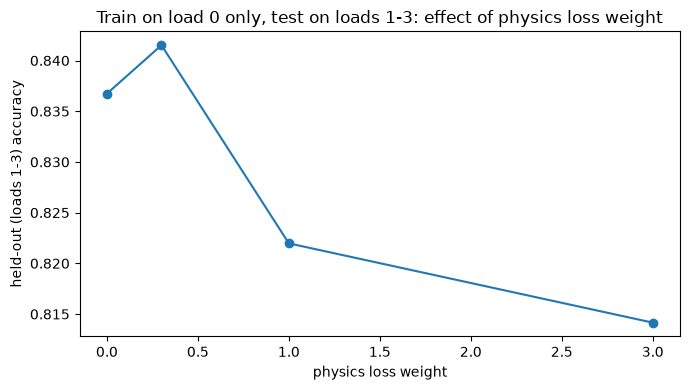

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(results.keys()), list(results.values()), marker="o")
ax.set_xlabel("physics loss weight")
ax.set_ylabel("held-out (loads 1-3) accuracy")
ax.set_title("Train on load 0 only, test on loads 1-3: effect of physics loss weight")
fig.tight_layout()
plt.savefig(Path.cwd().parent / "docs" / "phase5_weight_sweep.png", dpi=150)
plt.show()


## Classification detail for the best physics-informed model vs. the plain baseline

In [6]:
best_weight = max((w for w in results if w > 0), key=lambda w: results[w])
print(f"best physics_weight (excluding 0.0): {best_weight}, accuracy = {results[best_weight]:.4f}")
print(f"plain baseline (physics_weight=0.0): accuracy = {results[0.0]:.4f}")

for weight, title in [(0.0, "Plain (physics_weight=0)"), (best_weight, f"Physics-informed (weight={best_weight})")]:
    pred_labels = le.inverse_transform(predictions[weight]["class_preds"])
    true_labels = le.inverse_transform(predictions[weight]["targets"])
    print(f"\n=== {title} ===")
    print(classification_report(true_labels, pred_labels, zero_division=0))


best physics_weight (excluding 0.0): 0.3, accuracy = 0.8415
plain baseline (physics_weight=0.0): accuracy = 0.8367

=== Plain (physics_weight=0) ===
              precision    recall  f1-score   support

        B007       0.88      1.00      0.93       177
        B014       0.99      1.00      1.00       177
        B021       1.00      0.84      0.91       177
       IR007       1.00      1.00      1.00       178
       IR014       0.00      0.00      0.00       177
       IR021       1.00      1.00      1.00       177
      Normal       1.00      1.00      1.00       709
       OR007       1.00      0.04      0.08       177
       OR014       0.47      1.00      0.64       177
       OR021       0.54      1.00      0.70       177

    accuracy                           0.84      2303
   macro avg       0.79      0.79      0.73      2303
weighted avg       0.84      0.84      0.79      2303


=== Physics-informed (weight=0.3) ===
              precision    recall  f1-score   support

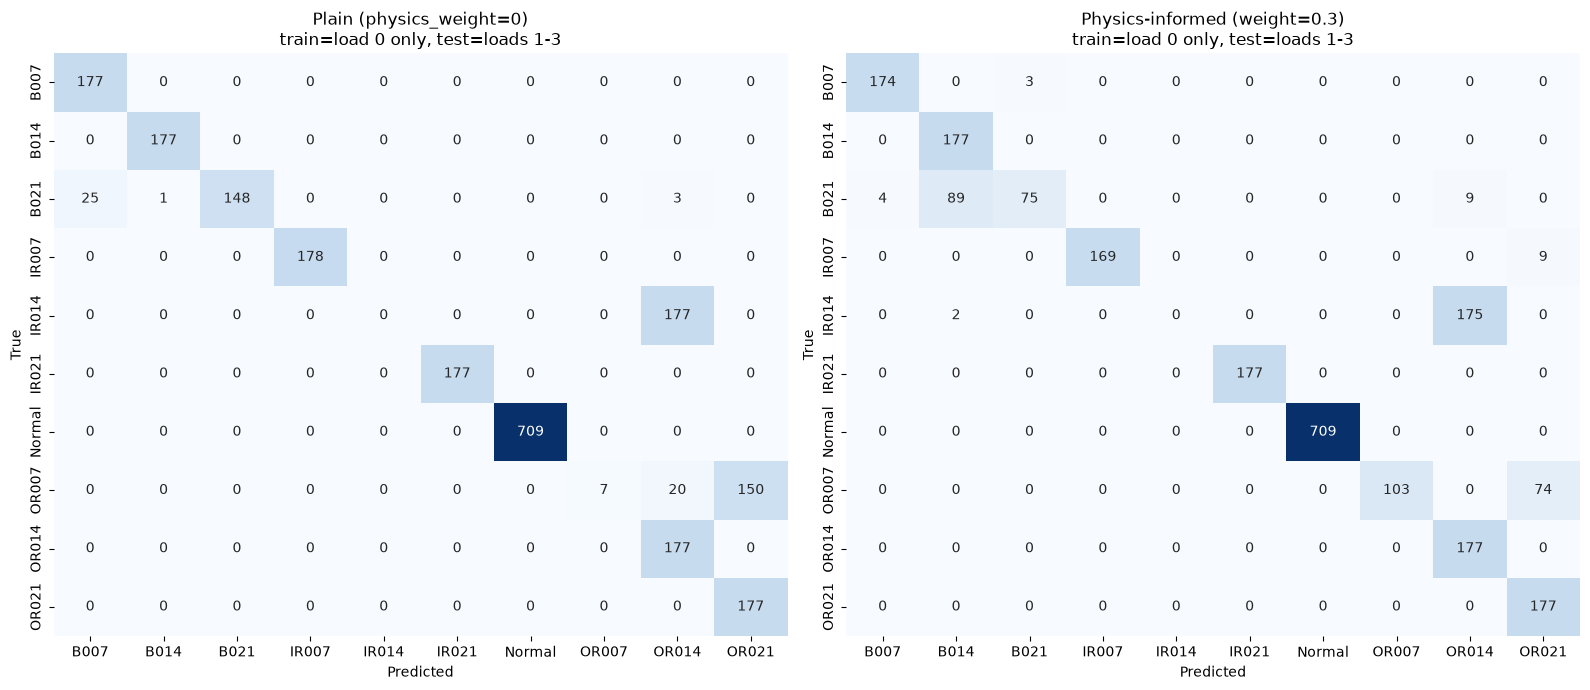

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, weight, title in [(axes[0], 0.0, "Plain (physics_weight=0)"),
                            (axes[1], best_weight, f"Physics-informed (weight={best_weight})")]:
    pred_labels = le.inverse_transform(predictions[weight]["class_preds"])
    true_labels = le.inverse_transform(predictions[weight]["targets"])
    cm = confusion_matrix(true_labels, pred_labels, labels=class_names)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False)
    ax.set_title(f"{title}\ntrain=load 0 only, test=loads 1-3")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
fig.tight_layout()
plt.savefig(Path.cwd().parent / "docs" / "phase5_confusion_matrices.png", dpi=150)
plt.show()


## The real physics test: does the auxiliary head extrapolate to unseen RPMs?

Training data is entirely from RPM 1797 - the model has never seen a single example of the
defect frequency at any other speed. If its physics head still tracks the correct frequency
at the three unseen RPMs (1772, 1750, 1730), that's genuine evidence of learning the physical
relationship rather than memorizing a training-set constant.


Physics head MAE on held-out loads 1-3 (fault windows only): 15.29 Hz


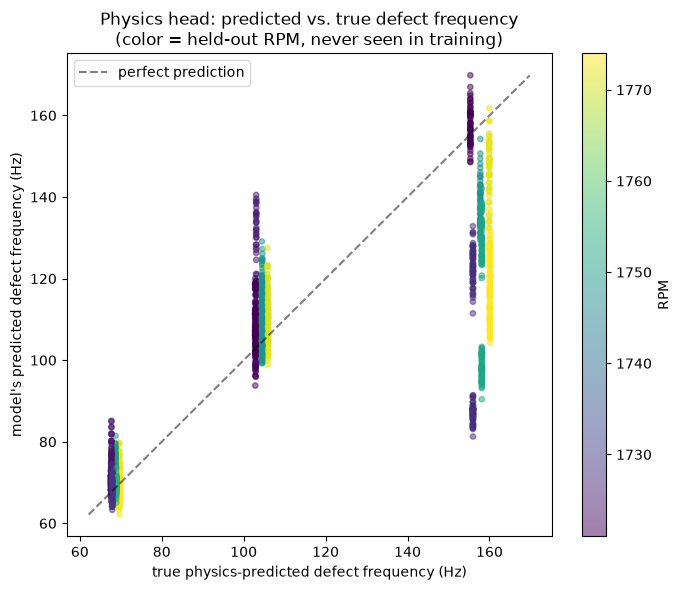

In [8]:
best_result = predictions[best_weight]
fault_mask = best_result["physics_masks"] == 1

pred_freq_hz = best_result["physics_preds"][fault_mask] * FREQ_SCALE_HZ
true_freq_hz = best_result["physics_targets"][fault_mask] * FREQ_SCALE_HZ
test_rpms_fault = rpms_test[fault_mask]

mae_hz = mean_absolute_error(true_freq_hz, pred_freq_hz)
print(f"Physics head MAE on held-out loads 1-3 (fault windows only): {mae_hz:.2f} Hz")

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(true_freq_hz, pred_freq_hz, c=test_rpms_fault, cmap="viridis", alpha=0.5, s=15)
lims = [min(true_freq_hz.min(), pred_freq_hz.min()), max(true_freq_hz.max(), pred_freq_hz.max())]
ax.plot(lims, lims, "k--", alpha=0.5, label="perfect prediction")
ax.set_xlabel("true physics-predicted defect frequency (Hz)")
ax.set_ylabel("model's predicted defect frequency (Hz)")
ax.set_title("Physics head: predicted vs. true defect frequency\n(color = held-out RPM, never seen in training)")
fig.colorbar(scatter, label="RPM")
ax.legend()
fig.tight_layout()
plt.savefig(Path.cwd().parent / "docs" / "phase5_physics_extrapolation.png", dpi=150)
plt.show()


## Summary

In [9]:
summary = pd.DataFrame([
    {"physics_weight": w, "held_out_loads_1to3_accuracy": acc} for w, acc in results.items()
])
summary


,physics_weight,held_out_loads_1to3_accuracy
0,0.0,0.836735
1,0.3,0.841511
2,1.0,0.821971
3,3.0,0.814155
